In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [4]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [5]:
# EDA

In [6]:
df['sex'].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

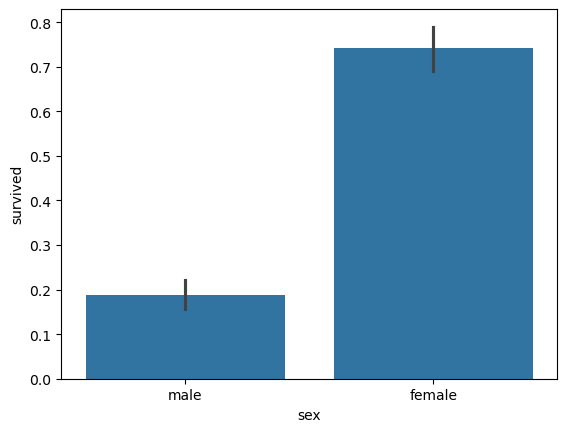

In [7]:
sns.barplot(data=df, x='sex', y="survived")
plt.show()

In [8]:
df["pclass"].value_counts()

pclass
3    491
1    216
2    184
Name: count, dtype: int64

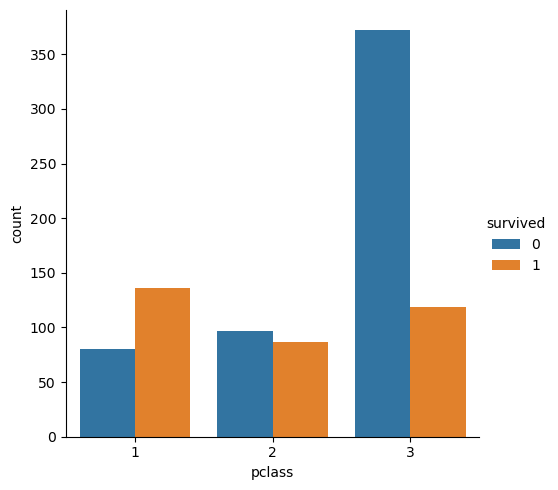

In [9]:
sns.catplot(data=df, x='pclass', hue="survived", kind="count")
plt.show()

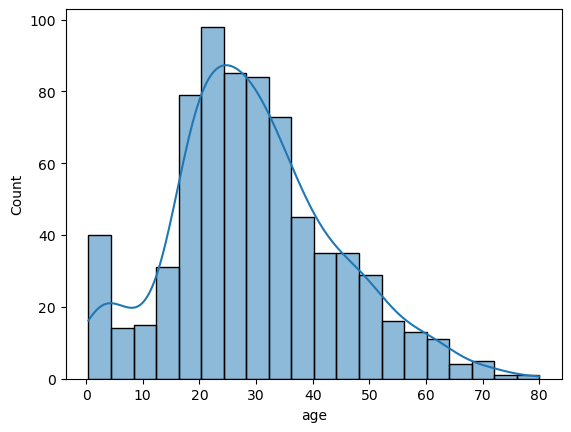

In [10]:
sns.histplot(data=df, x="age", kde=True)
plt.show()

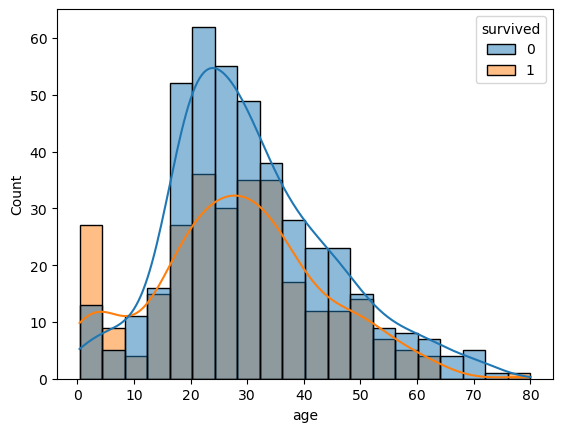

In [11]:
sns.histplot(data=df, x="age", hue="survived",kde=True)
plt.show()

In [12]:
df["who"].value_counts()

who
man      537
woman    271
child     83
Name: count, dtype: int64

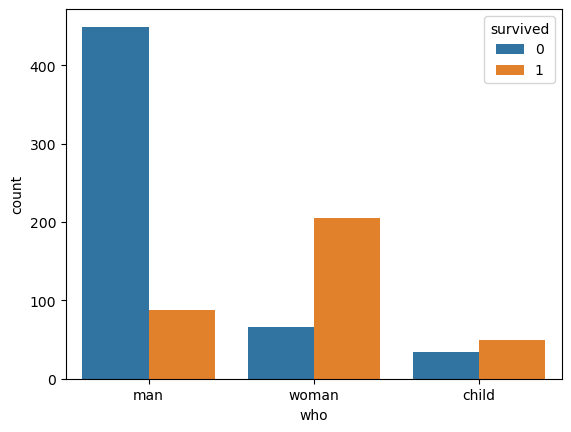

In [13]:
sns.countplot(data=df, x="who", hue="survived")
plt.show()

In [14]:
# feature engineering

In [15]:
df.shape

(891, 15)

In [16]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [17]:
df = df.drop(columns=["deck", "embark_town", "alive"], axis=1)

In [18]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [19]:
df["age"] = df["age"].fillna(df['age'].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

In [20]:
df.isnull().sum()

survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      0
class         0
who           0
adult_male    0
alone         0
dtype: int64

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   survived    891 non-null    int64   
 1   pclass      891 non-null    int64   
 2   sex         891 non-null    object  
 3   age         891 non-null    float64 
 4   sibsp       891 non-null    int64   
 5   parch       891 non-null    int64   
 6   fare        891 non-null    float64 
 7   embarked    891 non-null    object  
 8   class       891 non-null    category
 9   who         891 non-null    object  
 10  adult_male  891 non-null    bool    
 11  alone       891 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), object(3)
memory usage: 65.5+ KB


In [22]:
df["adult_male"] = df["adult_male"].astype(int)
df["alone"] = df["alone"].astype(int)

In [23]:
# dependent & independent features

X = df.drop("survived", axis=1)
y = df["survived"]

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15)

In [25]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [26]:
categorical_cols = ["sex", "class", "embarked", "who"]

preprocesser = ColumnTransformer(transformers=
                    [
                        ("OneHot", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)
                    ],
                    remainder="passthrough"
)

X_train = preprocesser.fit_transform(X_train)
X_test = preprocesser.transform(X_test)

In [27]:
encoded_cols = preprocesser.get_feature_names_out()

In [28]:
X_train = pd.DataFrame(X_train, columns=encoded_cols)
X_test = pd.DataFrame(X_test, columns=encoded_cols)

In [29]:
X_train.head()

,OneHot__sex_male,OneHot__class_Second,OneHot__class_Third,OneHot__embarked_Q,OneHot__embarked_S,OneHot__who_man,OneHot__who_woman,remainder__pclass,remainder__age,remainder__sibsp,remainder__parch,remainder__fare,remainder__adult_male,remainder__alone
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,2.0,2.0,1.0,1.0,26.0000,0.0,0.0
1,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,54.0,0.0,1.0,77.2875,1.0,0.0
2,0.0,1.0,0.0,0.0,1.0,0.0,1.0,2.0,21.0,0.0,0.0,10.5000,0.0,1.0
3,1.0,0.0,1.0,0.0,1.0,1.0,0.0,3.0,18.0,1.0,1.0,20.2125,1.0,0.0
4,1.0,0.0,1.0,0.0,1.0,1.0,0.0,3.0,20.0,1.0,0.0,7.9250,1.0,0.0


In [30]:
# model
# https://lightgbm.readthedocs.io/en/stable/
import lightgbm as lgb

In [31]:
classifier = lgb.LGBMClassifier(verbosity=-1)

In [32]:
classifier.fit(X_train, y_train)

LGBMClassifier(verbosity=-1)

In [33]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = classifier.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

[[82 21]
 [17 59]]

              precision    recall  f1-score   support

           0       0.83      0.80      0.81       103
           1       0.74      0.78      0.76        76

    accuracy                           0.79       179
   macro avg       0.78      0.79      0.78       179
weighted avg       0.79      0.79      0.79       179



In [34]:
importances = classifier.feature_importances_

feature_name = X_train.columns
feature_importance = pd.DataFrame(
    {
        "Feature": feature_name,
        "Importance": importances
    }
    
)

In [35]:
feature_importance.sort_values(by="Importance", ascending=False)

,Feature,Importance
11,remainder__fare,1191
8,remainder__age,913
9,remainder__sibsp,86
10,remainder__parch,84
4,OneHot__embarked_S,78
2,OneHot__class_Third,56
0,OneHot__sex_male,46
1,OneHot__class_Second,41
13,remainder__alone,40
3,OneHot__embarked_Q,38


In [36]:
# hyperparameter tuning
# https://lightgbm.readthedocs.io/en/stable/Parameters-Tuning.html

params = {
    "n_estimators": [100, 150, 200, 300],
    "learning_rate": [0.01, 0.1],
    "num_leaves": [15, 31, 63, 127],
    "min_child_samples": [10,20,30],
    "max_depth": [3,5,7],
    "subsample": [0.6,0.8],
    "colsample_bytree": [0.6,0.8]
}

In [37]:
from sklearn.model_selection import RandomizedSearchCV

lgb_model = lgb.LGBMClassifier(verbosity=-1)

In [38]:
random_search = RandomizedSearchCV(estimator=lgb_model, param_distributions=params, cv=5, scoring="accuracy", n_jobs=-1, verbose=1)

In [39]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5, estimator=LGBMClassifier(verbosity=-1), n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8],
                                        'learning_rate': [0.01, 0.1],
                                        'max_depth': [3, 5, 7],
                                        'min_child_samples': [10, 20, 30],
                                        'n_estimators': [100, 150, 200, 300],
                                        'num_leaves': [15, 31, 63, 127],
                                        'subsample': [0.6, 0.8]},
                   scoring='accuracy', verbose=1)

In [40]:
random_search.best_params_

{'subsample': 0.6,
 'num_leaves': 15,
 'n_estimators': 150,
 'min_child_samples': 10,
 'max_depth': 7,
 'learning_rate': 0.1,
 'colsample_bytree': 0.6}

In [41]:
y_pred = random_search.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

[[88 15]
 [18 58]]

              precision    recall  f1-score   support

           0       0.83      0.85      0.84       103
           1       0.79      0.76      0.78        76

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



In [43]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=100)
xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

[[84 19]
 [17 59]]

              precision    recall  f1-score   support

           0       0.83      0.82      0.82       103
           1       0.76      0.78      0.77        76

    accuracy                           0.80       179
   macro avg       0.79      0.80      0.79       179
weighted avg       0.80      0.80      0.80       179



In [44]:
param_grid = {
    "n_estimators": [100, 150, 200, 300],
    "learning_rate": [0.01, 0.1],
    "max_depth": [3,5,7],
    "colsample_bytree": [0.6,0.8]
}

In [45]:
random_search = RandomizedSearchCV(estimator=XGBClassifier(), param_distributions=param_grid, cv=5, scoring="accuracy", n_jobs=-1, verbose=1)

In [46]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constrain...
                                           max_delta_step=None, max_depth=None,
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8],
                                        'learning_rate': [0.01, 0.1],
                                        'max_depth': [3, 5, 7],
                                        'n_estimators': [100, 150, 200, 300]},
                   scoring='accuracy', verbose=1)

In [47]:
random_search.best_params_

{'n_estimators': 300,
 'max_depth': 3,
 'learning_rate': 0.1,
 'colsample_bytree': 0.8}

In [48]:
y_pred = random_search.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

[[88 15]
 [17 59]]

              precision    recall  f1-score   support

           0       0.84      0.85      0.85       103
           1       0.80      0.78      0.79        76

    accuracy                           0.82       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.82      0.82      0.82       179

